In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.widgets import RadioButtons, CheckButtons
import networkx as nx
from matplotlib.lines import Line2D

In [2]:
expr = pd.read_csv('data/expression_matrix.csv', index_col='gene_id')
metadata = pd.read_csv('data/sample_metadata.csv', index_col='sample_id')

# Align samples
samples = expr.columns.intersection(metadata.index)
expr = expr[samples]
metadata = metadata.loc[samples]

tumor_samples  = metadata[metadata['condition'] == 'tumor'].index
normal_samples = metadata[metadata['condition'] == 'normal'].index

# Per-gene statistics
mean_tumor  = expr[tumor_samples].mean(axis=1)
mean_normal = expr[normal_samples].mean(axis=1)
log2fc      = mean_tumor - mean_normal   # log2 fold-change (already in log2 space)

# Per-gene p-value (Welch t-test, one per gene)
pvalues = expr.apply(
    lambda row: stats.ttest_ind(
        row[tumor_samples], row[normal_samples], equal_var=False
    ).pvalue,
    axis=1
)
neg_log10_p = -np.log10(pvalues.clip(lower=1e-300))

print(f"Genes: {expr.shape[0]}  |  Tumor samples: {len(tumor_samples)}  |  Normal samples: {len(normal_samples)}")

Genes: 200  |  Tumor samples: 40  |  Normal samples: 20


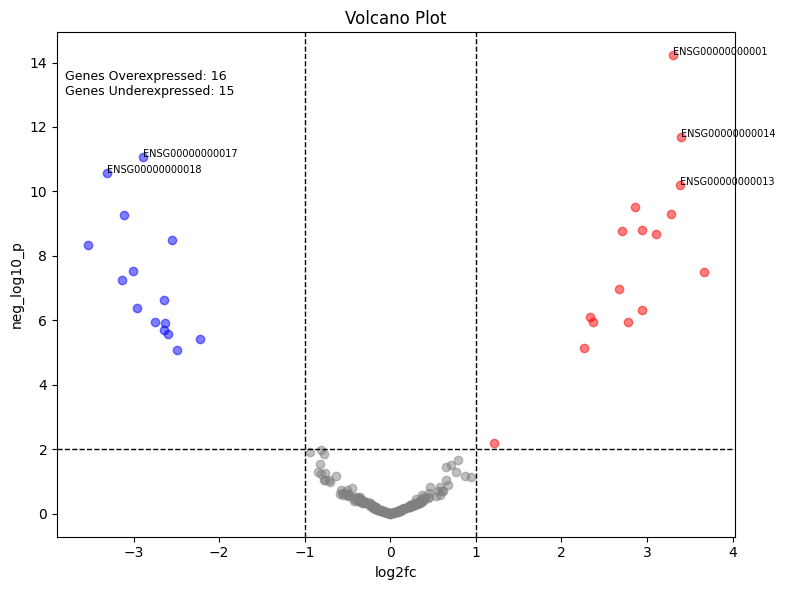

In [3]:
def volcanoPlot(ax, log2fc, neg_log10_p):
    # Assigning the x and y values to the correct variables
    x = log2fc
    y = neg_log10_p

    # Creating a mask with the established thresholds
    mask_plus = (log2fc>1) & (neg_log10_p>2)
    mask_minus = (log2fc<-1) & (neg_log10_p>2)
    mask_notsig = ((log2fc>-1) & (log2fc<1) & (neg_log10_p<2))

    # Plotting the volcano plot
    ax.scatter(x[mask_plus], y[mask_plus], color= 'red', alpha=0.5)
    ax.scatter(x[mask_minus], y[mask_minus], color = 'blue', alpha= 0.5)
    ax.scatter(x[mask_notsig], y[mask_notsig], color = 'grey', alpha= 0.5)
    ax.axvline(1, color= 'black', linestyle = '--', linewidth= 1)
    ax.axvline(-1, color= 'black', linestyle = '--', linewidth= 1)
    ax.axhline(2, color= 'black', linestyle = '--', linewidth=1)
    ax.set_xlabel('log2fc')
    ax.set_ylabel('neg_log10_p')
    ax.set_title('Volcano Plot')

    # Annotate the plot for the five most significant genes (neg_log10_p)
    top5 = np.argsort(y)[-5:]
    for i in top5:
        ax.text(log2fc.iloc[i], neg_log10_p.iloc[i], neg_log10_p.index[i], size=7)

    # Summary text
    up= x[mask_plus]
    down= x[mask_minus]
    ax.text(-3.8, 13, f'Genes Overexpressed: {len(up)} \nGenes Underexpressed: {len(down)}', size=9)

#test
fig, ax = plt.subplots(figsize=(8, 6))
volcanoPlot(ax, log2fc, neg_log10_p)
plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150)
plt.show()

In [4]:
neg_log10_p.head()

gene_id
ENSG00000000001    14.225322
ENSG00000000002     5.949471
ENSG00000000003     9.295034
ENSG00000000004     8.788228
ENSG00000000005     6.971753
dtype: float64

In [5]:
log2fc.head()

gene_id
ENSG00000000001    3.300540
ENSG00000000002    2.772576
ENSG00000000003    3.280127
ENSG00000000004    2.705577
ENSG00000000005    2.677098
dtype: float64

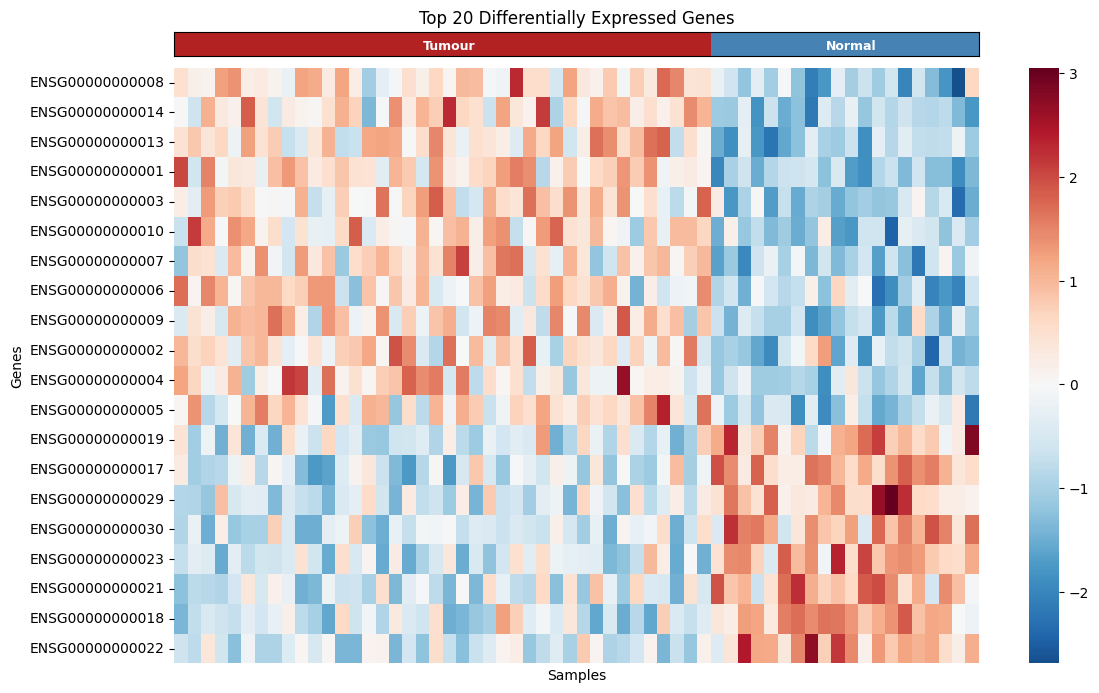

In [6]:
# Get the top 20 most differentially expressed genes higher to lower

def expressionHeatmap(ax, expr, metadata):

    tumor_samples  = metadata[metadata['condition'] == 'tumor']
    normal_samples = metadata[metadata['condition'] == 'normal']

    mean_tumor  = expr[tumor_samples.index].mean(axis=1)
    mean_normal = expr[normal_samples.index].mean(axis=1)
    log2fc      = mean_tumor - mean_normal

    abs_fc= log2fc.abs().sort_values(ascending=False).head(20).index
    ordered_genes = log2fc.loc[abs_fc].sort_values(ascending=False).index

    #ordering the metadata (tumour + normal)
    tumor_ordered = tumor_samples.sort_values(by='cancer_type')

    normal_ordered = normal_samples.sort_values(by='cancer_type')

    ordered_samples = (list(tumor_ordered.index) +list(normal_ordered.index))
    
    #mask for the heatmap
    heatmap = expr.loc[ordered_genes, ordered_samples]

    #z-score normalization
    z_score_norm= heatmap.sub(heatmap.mean(axis=1), axis=0).div(heatmap.std(axis=1), axis=0)

    #tumour vs normal annotation
    condition_bar = np.array([
        1 if s in tumor_samples.index else 0
        for s in ordered_samples
    ]).reshape(1, -1)

    # create small axis above heatmap
    top_ax = ax.inset_axes([0, 1.02, 1, 0.04])

    top_ax.imshow(
        condition_bar,
        aspect='auto',
        cmap=ListedColormap(['steelblue', 'firebrick'])
    )

    top_ax.set_xticks([])
    top_ax.set_yticks([])

    n_tumor = len(tumor_samples)
    n_normal = len(normal_samples)

    top_ax.text(
        n_tumor / 2,
        0.1,
        'Tumour',
        ha='center',
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

    top_ax.text(
        n_tumor + n_normal / 2,
        0.1,
        'Normal',
        ha='center',
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

    #draw heatmap
    sns.heatmap(
            z_score_norm,
            ax=ax,
            cmap='RdBu_r',
            center=0,
            cbar=True,
            xticklabels=False,
            yticklabels=True
        )

    ax.set_title('Top 20 Differentially Expressed Genes')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Genes')

#test
fig, ax = plt.subplots(figsize=(12, 7))
expressionHeatmap(ax, expr, metadata)
plt.tight_layout()
plt.savefig('expression_heatmap.png', dpi=150)
plt.show()




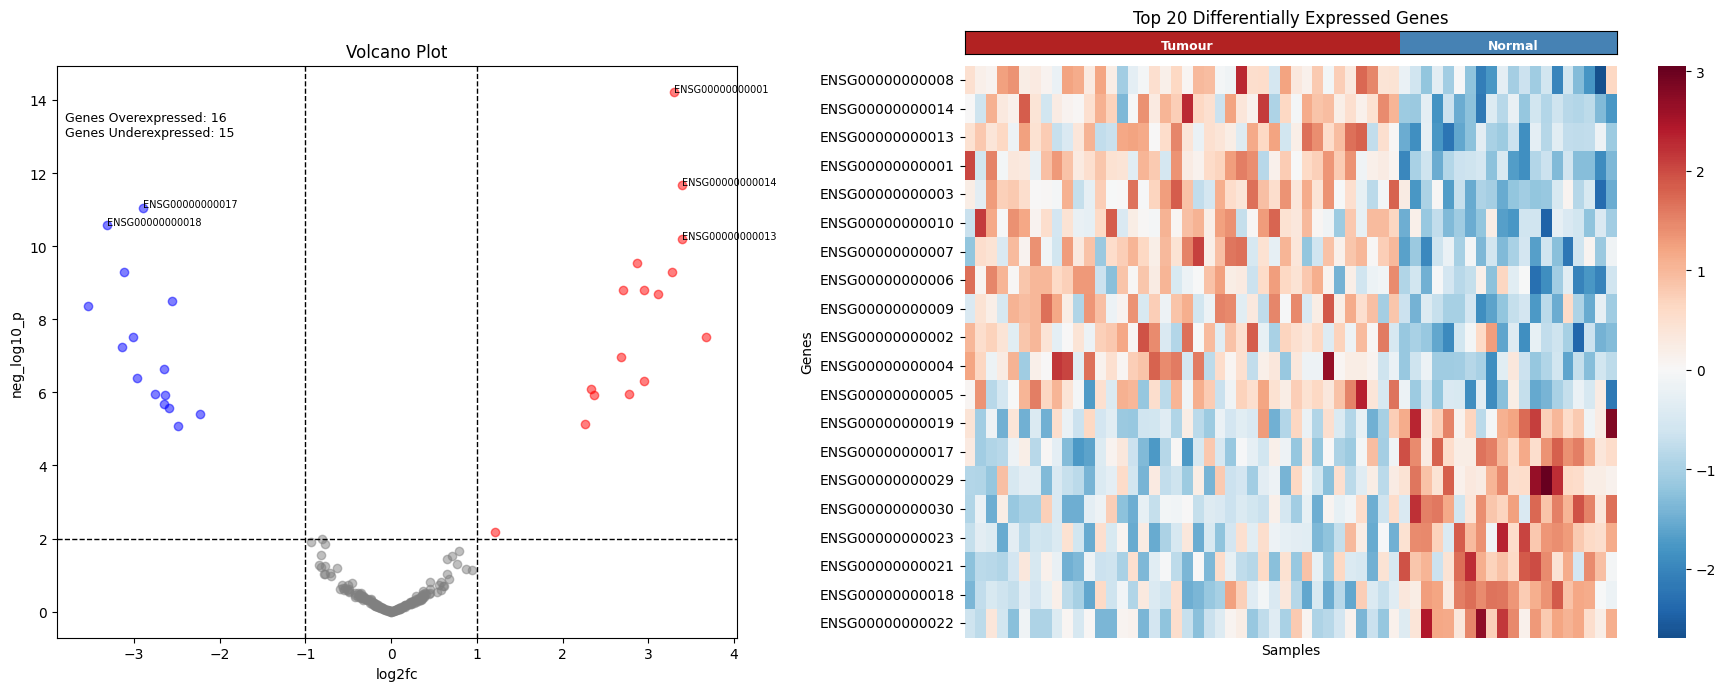

In [7]:
def expressionSummaryFigure(expr, metadata):
    fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    gridspec_kw={'width_ratios': [1, 1.2]}
)

    # left = volcano
    volcanoPlot(axes[0], log2fc, neg_log10_p)

    # right = heatmap
    expressionHeatmap(axes[1], expr, metadata)

    plt.tight_layout()

    plt.savefig('expression_summary.png', dpi=150, bbox_inches='tight')

    plt.show()

# Test
expressionSummaryFigure(expr, metadata)

In [8]:
#Task II

from matplotlib.widgets import RadioButtons, CheckButtons

snps = pd.read_csv('data/snp_surveillance.csv')
populations = sorted(snps['population'].unique())
chromosomes = sorted(snps['chromosome'].unique(), key=lambda x: (int(x) if x.isdigit() else 100, x))
consequences = sorted(snps['consequence'].unique())
years = sorted(snps['year'].unique())

print(snps.head(20))
print(f"\n{len(snps)} records | {snps['snp_id'].nunique()} unique SNPs | {len(populations)} populations")

      snp_id chromosome population  year  allele_frequency  consequence  \
0   rs590157          3        AMR  2018            0.0955   synonymous   
1   rs834025         13        AFR  2017            0.2897  stop_gained   
2   rs986414         11        EUR  2016            0.1248   synonymous   
3   rs153501         20        AMR  2016            0.0082   synonymous   
4   rs317703          6        AFR  2016            0.0404  stop_gained   
5   rs640982          6        SAS  2015            0.2071     missense   
6   rs990158          3        EUR  2018            0.3682   synonymous   
7   rs477771          2        AMR  2022            0.0536  stop_gained   
8   rs217851         22        AMR  2019            0.1078   synonymous   
9   rs822128         21        EUR  2022            0.0514     intronic   
10  rs202313          5        EUR  2018            0.0165  stop_gained   
11  rs223940         14        AFR  2023            0.1414  stop_gained   
12  rs331348         11  

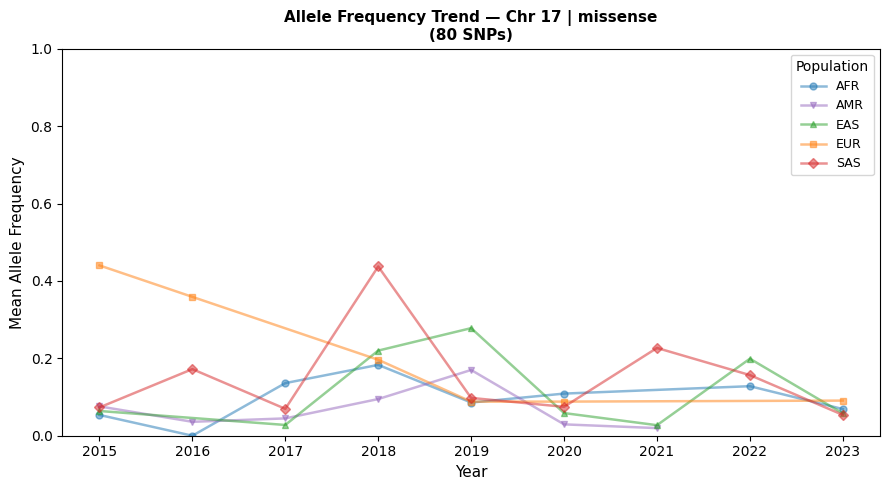

In [9]:
def drawPopulationTrend(ax, chromosome, consequence):

    snps = pd.read_csv('data/snp_surveillance.csv')
    subset = snps[(snps['chromosome'].astype(str) == str(chromosome)) &
                  (snps['consequence'] == consequence)]
 
    if subset.empty:
        ax.text(0.5, 0.5, 'No data for this selection.',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Chr {chromosome} | {consequence}')
        return
 
    trend = (subset.groupby(['year', 'population'])['allele_frequency']
             .mean().reset_index())
    
    colors = {
    "AFR": "tab:blue",
    "EUR": "tab:orange",
    "EAS": "tab:green",
    "SAS": "tab:red",
    "AMR": "tab:purple",
    }

    markers = {
    "AFR": "o",
    "EUR": "s",
    "EAS": "^",
    "SAS": "D",
    "AMR": "v",
    }
    
    for pop in sorted(trend['population'].unique()):
        d = trend[trend['population'] == pop].sort_values('year')
        ax.plot(d['year'], d['allele_frequency'],
                label=pop,
                color=colors.get(pop, None),
                marker=markers.get(pop, 'o'),
                linewidth=1.8, markersize=5, alpha=0.5)
 
    n_snps = subset['snp_id'].nunique()
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Mean Allele Frequency', fontsize=11)
    ax.set_title(f'Allele Frequency Trend — Chr {chromosome} | {consequence}\n'
                 f'({n_snps} SNPs)', fontsize=11, fontweight='bold')
    ax.legend(title='Population', fontsize=9, loc='best')
    ax.set_ylim(0, 1)

# Test
fig, ax = plt.subplots(figsize=(9, 5))
drawPopulationTrend(ax, '17', 'missense')
plt.tight_layout()
plt.savefig('population_trend.png', dpi=150)
plt.show()

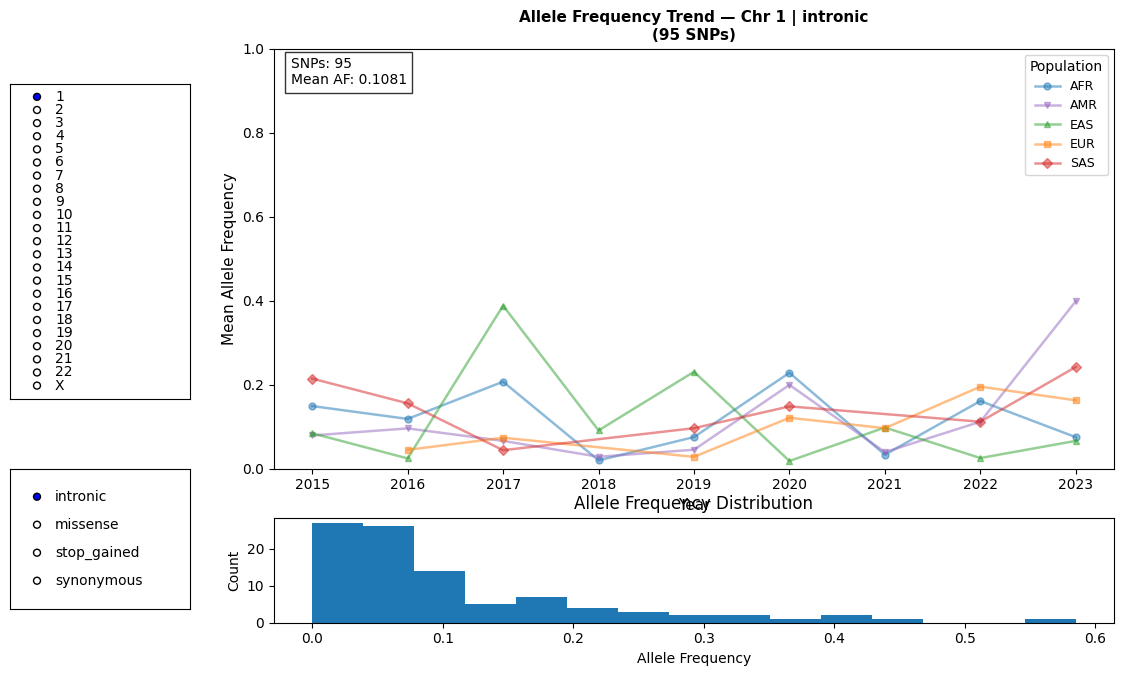

In [10]:
def drawSurveillanceDashboard():
    """
    Interactive matplotlib dashboard for SNP surveillance data.
    """

    current_chr = chromosomes[0]
    current_cons = consequences[0]

    fig = plt.figure(figsize=(12, 7))

    # Main trend plot
    ax_trend = fig.add_axes([0.25, 0.30, 0.70, 0.60])

    # Distribution plot
    ax_dist = fig.add_axes([0.25, 0.08, 0.70, 0.15])

    # Radio buttons
    ax_chr = fig.add_axes([0.03, 0.40, 0.15, 0.45])
    radio_chr = RadioButtons(ax_chr, chromosomes)

    ax_cons = fig.add_axes([0.03, 0.10, 0.15, 0.20])
    radio_cons = RadioButtons(ax_cons, consequences)

    def update():
        ax_trend.clear()
        ax_dist.clear()

        # Main trend plot (T2.1)
        drawPopulationTrend(ax_trend, current_chr, current_cons)

        # Data for current selection
        subset = snps[
            (snps["chromosome"].astype(str) == current_chr) &
            (snps["consequence"] == current_cons)
        ]

        if len(subset) == 0:
            ax_dist.text(
                0.5, 0.5,
                "No data available",
                ha="center",
                va="center",
                transform=ax_dist.transAxes
            )
        else:
            # Histogram
            ax_dist.hist(
                subset["allele_frequency"],
                bins=15
            )
            ax_dist.set_title("Allele Frequency Distribution")
            ax_dist.set_xlabel("Allele Frequency")
            ax_dist.set_ylabel("Count")

            # Summary statistics
            stats_text = (
                f"SNPs: {len(subset)}\n"
                f"Mean AF: {subset['allele_frequency'].mean():.4f}"
            )

            ax_trend.text(
                0.02, 0.98,
                stats_text,
                transform=ax_trend.transAxes,
                va="top",
                bbox=dict(facecolor="white", alpha=0.8)
            )

        fig.canvas.draw_idle()

    def chromosome_changed(label):
        nonlocal current_chr
        current_chr = label
        update()

    def consequence_changed(label):
        nonlocal current_cons
        current_cons = label
        update()

    radio_chr.on_clicked(chromosome_changed)
    radio_cons.on_clicked(consequence_changed)

    update()
    plt.show()

# test
drawSurveillanceDashboard()

In [11]:
metabolites=pd.read_csv("data/metabolites.csv")
reactions=pd.read_csv("data/reactions.csv")

In [12]:
#T4.1
def buildMetabolicGraph(metabolites, reactions):

    G = nx.DiGraph()

    # Add metabolites as nodes
    for metabolite_id, row in metabolites.iterrows():
        G.add_node(
            metabolite_id,
            name=row["name"],
            pathway=row["pathway"],
            formula=row["formula"]
        )

    # Add reactions as edges
    for _, row in reactions.iterrows():

        edge_attrs = {
            "reaction_id": row["reaction_id"],
            "enzyme": row["enzyme"],
            "reversible": row["reversible"],
            "delta_G": row["delta_G"]
        }

        # Forward reaction
        G.add_edge(
            row["source"],
            row["target"],
            **edge_attrs
        )

        # Reverse reaction if reversible
        if bool(row["reversible"]):
            G.add_edge(
                row["target"],
                row["source"],
                **edge_attrs
            )

    return G

#test
G = buildMetabolicGraph(metabolites, reactions)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 46 nodes, 36 edges


KeyError: 'pathway'

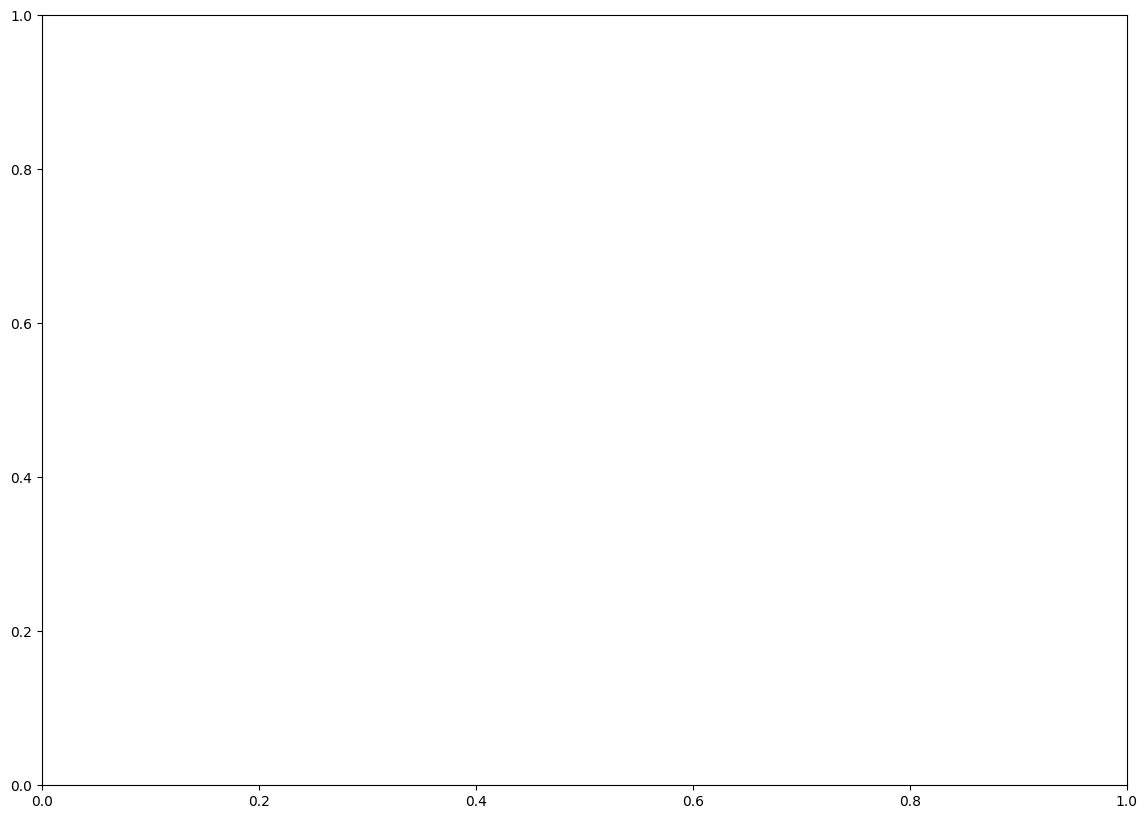

In [13]:
def drawMetabolicNetwork(ax, G, metabolites):

    # Layout
    pos = nx.kamada_kawai_layout(G)

    # Pathway colours
    pathway_colors = {
        "Glycolysis": "#1f77b4",
        "TCA": "#2ca02c",
        "PPP": "#ff7f0e",
        "Shared": "#9467bd"
    }

    # Node appearance
    node_colors = [
        pathway_colors.get(
            G.nodes[n]["pathway"],
            "lightgray"
        )
        for n in G.nodes()
    ]

    node_sizes = [
        300 + 100 * G.degree(n)
        for n in G.nodes()
    ]

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9,
        ax=ax
    )

    # Edge groups
    favorable = []
    unfavorable = []
    reversible = []
    irreversible = []

    for u, v, data in G.edges(data=True):

        if data["delta_G"] < 0:
            favorable.append((u, v))
        else:
            unfavorable.append((u, v))

        if data["reversible"]:
            reversible.append((u, v))
        else:
            irreversible.append((u, v))

    # Draw edges by style and colour
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=irreversible,
        edge_color=[
            "green" if G[u][v]["delta_G"] < 0 else "red"
            for u, v in irreversible
        ],
        style="solid",
        arrows=True,
        alpha=0.8,
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=reversible,
        edge_color=[
            "green" if G[u][v]["delta_G"] < 0 else "red"
            for u, v in reversible
        ],
        style="dashed",
        arrows=True,
        alpha=0.8,
        ax=ax
    )

    # Labels from graph attributes
    labels = {
        n: G.nodes[n]["name"]
        for n in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_size=7,
        ax=ax
    )

    # Legend
    pathway_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=color,
            markersize=10,
            label=pathway
        )
        for pathway, color in pathway_colors.items()
    ]

    edge_handles = [
        Line2D([0], [0], color='green', lw=2,
               label='ΔG < 0'),
        Line2D([0], [0], color='red', lw=2,
               label='ΔG > 0'),
        Line2D([0], [0], color='black', lw=2,
               linestyle='solid',
               label='Irreversible'),
        Line2D([0], [0], color='black', lw=2,
               linestyle='dashed',
               label='Reversible')
    ]

    ax.legend(
        handles=pathway_handles + edge_handles,
        loc='upper right'
    )

    ax.set_title("Metabolic Network")
    ax.axis("off")
    
# Test
fig, ax = plt.subplots(figsize=(14, 10))
drawMetabolicNetwork(ax, G, metabolites)
plt.tight_layout()
plt.savefig('metabolic_network.png', dpi=150)
plt.show()

In [ ]:
print(metabolites.columns)
print(list(G.nodes(data=True))[:5])

Index(['metabolite_id', 'name', 'pathway', 'formula'], dtype='object')
[(0, {'name': 'Glucose', 'pathway': 'Glycolysis', 'formula': 'C6H12O6'}), (1, {'name': 'Glucose-6P', 'pathway': 'Glycolysis', 'formula': 'C6H13O9P'}), (2, {'name': 'Fructose-6P', 'pathway': 'Glycolysis', 'formula': 'C6H13O9P'}), (3, {'name': 'Fructose-1,6BP', 'pathway': 'Glycolysis', 'formula': 'C6H14O12P2'}), (4, {'name': 'G3P', 'pathway': 'Glycolysis', 'formula': 'C3H7O6P'})]


In [ ]:
print(metabolites["pathway"].value_counts())


pathway
Glycolysis    9
TCA           8
PPP           4
Shared        2
Name: count, dtype: int64


In [ ]:
xs = [1,2,3]
print(xs[-1])
print(xs[1:])
print(xs[:-1])
print(xs[-1:])
print(xs[::-1])


3
[2, 3]
[1, 2]
[3]
[3, 2, 1]


In [ ]:
import datetime
print(datetime.datetime.now())

2026-06-03 16:35:31.130685


In [ ]:
print(7%4)

3


In [ ]:
message ="Hi There "
print ( message + " " + " Jonh Snow ") 
print ( message * 3)
print(message.casefold())
print(message.capitalize())
print(len(message))

Hi There   Jonh Snow 
Hi There Hi There Hi There 
hi there 
Hi there 
9


In [ ]:
def y(v0 , t):
    g = 9.8
    return v0 * t - 1/2 * g * (t **2)

In [ ]:
y(1,2)

-17.6

In [ ]:
fruit = " banana "
fruits = list ( enumerate ( fruit ))
triple = (1 , fruit , False )
print(triple[2])


False


In [ ]:
p = ("a", (2 , 3.5) , [3 , 4 , 5 , 6])
(p1 , ( p21 , p22 ) , [ p31 , * p32 , p33 ]) = p
print(p1)


a


In [ ]:
list = [3 , 1, 2]
list = list . sort ()
print(list)

None


In [ ]:
a = [1 , 2, 3]
b = a [:]
# or b = list (a)
# or b = a. copy ()
b [0] = 0
print (a , b)


[1, 2, 3] [0, 2, 3]


In [ ]:
xs = [1 , 2, 3]
ys = ['a','b', 'c']
zs = xs + ys
print (xs , ys , zs )

[1, 2, 3] ['a', 'b', 'c'] [1, 2, 3, 'a', 'b', 'c']


In [ ]:
def remove_chars ( chars , phrase ) :
    string_sans_chars = ""
    for letter in phrase :
        if letter not in chars :
            string_sans_chars += letter

    return string_sans_chars

new_word = remove_chars (" aeiou ", " Hello World ")
print (new_word)
print(type(new_word))


HllWrld
<class 'str'>


TypeError: 'NoneType' object is not callable

In [ ]:
zs = ['x', 'y', 'z']
ws = [1 , 2, 3, 4, 5]

print(list(zip(zs , ws )))
#[( ’x ’, 1) , ( ’y ’, 2) , ( ’z ’, 3)]


TypeError: 'NoneType' object is not callable